In [1]:
%edit
%load_ext autoreload
%autoreload 2

IPython will make a temporary file named: /tmp/ipython_edit_ra835m2t/ipython_edit_crb5ux7d.py


In [2]:
import matplotlib
matplotlib.use('Agg')

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

In [3]:
'''
Developed by Gengchen Mai

gengchen.mai@gmail.com
05/08/2019
'''


from argparse import ArgumentParser

from spacegraph_codebase.utils import *
from spacegraph_codebase.Place2Vec.cur_data_utils import load_pointset
from spacegraph_codebase.data_utils import load_ng
from spacegraph_codebase.model import NeighGraphEncoderDecoder
from spacegraph_codebase.train_helper import run_train, run_eval, run_joint_train

from torch import optim
import numpy as np

In [47]:
from spacegraph_codebase.trainer import make_args_parser, make_args_combine
parser = make_args_parser()

In [ ]:
import shlex

sh_file = "Place2Vec_2_enc_dec_global_theory.sh"
# sh_file = "spacegraph/Place2Vec_2_enc_dec_global_theory.sh"

with open(sh_file, "r") as f:
    command = f.read()

# "\" + 改行を除去
command = command.replace("\\\n", " ")

tokens = shlex.split(command, comments=True)

# "python -m spacegraph_codebase.Place2Vec.train" の後ろだけ取得
args_list = tokens[3:]

args = parser.parse_args(args_list)

print(1)
print(args)


1
Namespace(data_dir='./data_collection/Place2Vec_center/', model_dir='./model_dir/Place2Vec_center/', log_dir='./model_dir/Place2Vec_center/', num_context_sample=10, embed_dim=64, dropout=0.5, enc_agg='mean', model_type='global', num_rbf_anchor_pts=0, rbf_kernal_size=1000.0, rbf_kernal_size_ratio=0, spa_enc='theory', spa_embed_dim=64, freq=16, max_radius=10000.0, min_radius=100.0, spa_f_act='sigmoid', freq_init='geometric', spa_enc_use_layn='F', spa_enc_use_postmat='T', g_spa_enc='theory', g_spa_embed_dim=64, g_freq=32, g_max_radius=40000.0, g_min_radius=50.0, g_spa_f_act='relu', g_freq_init='geometric', g_spa_enc_use_layn='T', g_spa_enc_use_postmat='T', num_hidden_layer=1, hidden_dim=512, use_layn='T', skip_connection='T', use_dec='T', init_decoder_atten_type='concat', init_decoder_atten_act='leakyrelu', init_decoder_atten_f_act='sigmoid', init_decoder_atten_num=1, init_decoder_use_layn='T', init_decoder_use_postmat='T', decoder_atten_type='concat', decoder_atten_act='leakyrelu', dec

In [32]:
print("Loading NeighGraph data..")

print("Loading training NeighGraph data..")
train_ng_list = load_ng(args.data_dir + "/neighborgraphs_training.pkl")
print("Loading validation NeighGraph  data..")
val_ng_list = load_ng(args.data_dir + "/neighborgraphs_validation.pkl")
print("Loading testing NeighGraph data..")
test_ng_list = load_ng(args.data_dir + "/neighborgraphs_test.pkl")

Loading NeighGraph data..
Loading training NeighGraph data..
Loading validation NeighGraph  data..
Loading testing NeighGraph data..


In [33]:
def make_enc_dec(args):
    args_combine = make_args_combine(args)
    
    log_file = args.log_dir + args_combine + ".log"
    model_file = args.model_dir + args_combine + ".pth"

    logger = setup_logging(log_file, filemode='a')
    
    print("Loading PointSet data..")

    pointset, feature_embedding = load_pointset(data_dir=args.data_dir, 
                                                    embed_dim=args.embed_dim,
                                                    do_feature_sampling = False)
    if args.cuda:
        pointset.feature_embed_lookup = cudify(feature_embedding)
        
    # make feature encoder
    enc = get_encoder(pointset.feature_embed_lookup, feature_embedding, pointset, args.enc_agg)

    if args.model_type == "relative" or args.model_type == "join" or args.model_type == "together":
        # make relative space encoder
        spa_enc = get_spa_encoder(args=args,
                            model_type=args.model_type,
                            spa_enc_type=args.spa_enc,
                            pointset=None, 
                            spa_embed_dim=args.spa_embed_dim, 
                            coord_dim = 2, 
                            frequency_num = args.freq, 
                            max_radius = args.max_radius,
                            # dropout = args.dropout,
                            freq_init = args.freq_init)
    else:
        spa_enc = None

    if args.model_type == "global" or args.model_type == "join" or args.model_type == "together":
        # make global space encoder
        g_spa_enc = get_spa_encoder(args=args,
                            model_type=args.model_type,
                            spa_enc_type=args.g_spa_enc, 
                            spa_embed_dim=args.g_spa_embed_dim,
                            pointset=None, 
                            coord_dim = 2, 
                            frequency_num = args.g_freq, 
                            max_radius = args.g_max_radius,
                            # dropout = args.dropout,
                            freq_init = args.g_freq_init)
    else:
        g_spa_enc = None

    # make decoder
    if args.model_type == "relative" or args.model_type == "join" or args.model_type == "together":

        # make query embedding initial decoder
        init_dec = get_context_decoder(dec_type=args.init_decoder_atten_type, 
                            query_dim=args.embed_dim, 
                            key_dim=args.embed_dim, 
                            spa_embed_dim=args.spa_embed_dim, 
                            g_spa_embed_dim=args.g_spa_embed_dim,
                            have_query_embed = False, 
                            num_attn = args.init_decoder_atten_num, 
                            activation = args.init_decoder_atten_act, 
                            f_activation = args.init_decoder_atten_f_act, 
                            layn = args.init_decoder_use_layn, 
                            use_postmat = args.init_decoder_use_postmat,
                            dropout = args.dropout)

        if args.use_dec == "T":
            # make decoder
            dec = get_context_decoder(dec_type=args.decoder_atten_type, 
                                query_dim=args.embed_dim, 
                                key_dim=args.embed_dim, 
                                spa_embed_dim=args.spa_embed_dim, 
                                g_spa_embed_dim=args.g_spa_embed_dim,
                                have_query_embed = True, 
                                num_attn = args.decoder_atten_num, 
                                activation = args.decoder_atten_act, 
                                f_activation = args.decoder_atten_f_act, 
                                layn = args.decoder_use_layn, 
                                use_postmat = args.decoder_use_postmat,
                                dropout = args.dropout)
        else:
            dec = None

        if args.model_type == "join":
            joint_dec = JointRelativeGlobalDecoder(feature_embed_dim = args.embed_dim, 
                            f_act = args.act, 
                            dropout = args.dropout,
                            join_type = args.join_dec_type)
        else:
            joint_dec = None

    else:
        init_dec = None
        dec = None
        joint_dec = None

    if args.model_type == "global" or args.model_type == "join":
        # make global space decoder
        g_spa_dec = DirectPositionEmbeddingDecoder(g_spa_embed_dim=args.g_spa_embed_dim, 
                            feature_embed_dim=args.embed_dim, 
                            f_act = args.act, 
                            dropout = args.dropout)
    else:
        g_spa_dec = None




    # if args.model_type == "global" or args.model_type == "relative":
    # make encoder encoder
    enc_dec = get_enc_dec(model_type=args.model_type, 
                        pointset=pointset, 
                        enc = enc, 
                        spa_enc = spa_enc, 
                        g_spa_enc = g_spa_enc, 
                        g_spa_dec = g_spa_dec, 
                        init_dec=init_dec, 
                        dec=dec, 
                        joint_dec=joint_dec, 
                        activation = args.act, 
                        num_context_sample = args.num_context_sample, 
                        num_neg_resample = 10)

    if args.cuda:
        enc_dec.cuda()

    if args.opt == "sgd":
        optimizer = optim.SGD(filter(lambda p : p.requires_grad, enc_dec.parameters()), lr=args.lr, momentum=0)
    elif args.opt == "adam":
        optimizer = optim.Adam(filter(lambda p : p.requires_grad, enc_dec.parameters()), lr=args.lr)

#     logger.info("Save file at {}".format(args_combine + ".pth"))
    print("Load model from {}".format(args_combine + ".pth"))
    enc_dec.load_state_dict(torch.load(model_file))
    return enc_dec

In [72]:
coords = []
interval = 1000
# latitude
for y in range(1600000, 1650000+interval, interval):
    coord = []
#     longitude
    for x in range(-1713000, -1670000+interval, interval):
        coord.append([x,y])
    coords.append(coord)

extent = (-1713000, -1670000, 1600000, 1650000)


In [35]:
rel_coords = []
for y in range(0, 10010, 10):
    coord = []
    for x in range(0, 10010, 10):
        coord.append([x,y])
    rel_coords.append(coord)

In [48]:
g_enc_dec = make_enc_dec(args)

Loading PointSet data..
Create 3 FeedForward NN!!!!!!!!!!
Load model from /Place2Vec_center-10-64-0.5-mean-global-0-1000.0-0.00-theory-64-32-40000.0-50.0-relu-geometric-T-T--1-512-T-T-T-concat-leakyrelu-sigmoid-1-T-T-concat-leakyrelu-sigmoid-1-T-T-max-sigmoid-adam-0.001000-512.pth


/home/mine/卒業論文/WLemb/spacegraph/spacegraph_codebase/module.py:96: FutureWarning: `nn.init.xavier_uniform` is now deprecated in favor of `nn.init.xavier_uniform_`.
  nn.init.xavier_uniform(self.linear.weight)


In [50]:
x = []
y = []
types = []
cnt = 0
select_cnt = 0
filter_out_ids = [1575, 2342, 6883, 10577, 16755, 17172, 21961, 24320]
for pt_id in g_enc_dec.pointset.pt_dict:
    cnt += 1
#     if pt_id not in filter_out_ids:
    point = g_enc_dec.pointset.pt_dict[pt_id]
    pt_coord = point.coord
    if pt_coord[0] > -1713000 and pt_coord[0] < -1670000 and \
    pt_coord[1] > 1600000 and pt_coord[1] < 1650000:
        select_cnt += 1
        x.append(pt_coord[0])
        y.append(pt_coord[1])
        types.append(point.features[0])
print(cnt)
print(select_cnt)

21813
21813


In [61]:
from collections import Counter

type_counts = Counter(types)
print("POIタイプ数:", len(set(types)))

for type_id, count in Counter(types).most_common():
    print(type_id, count)

POIタイプ数: 765
0 1740
1 987
3 778
2 704
4 662
6 615
8 488
9 439
5 414
20 318
10 279
7 275
12 262
19 253
11 242
28 227
18 222
25 216
34 211
14 200
33 194
15 193
30 183
22 176
53 168
13 161
16 142
39 133
127 128
27 122
17 122
26 114
21 108
35 107
40 97
42 95
32 91
23 90
37 90
24 88
52 86
49 85
45 84
60 83
80 80
58 80
51 79
29 79
125 77
110 75
36 75
44 75
48 74
46 73
105 70
31 69
55 69
65 68
43 68
73 67
41 65
85 64
50 64
72 64
93 63
69 63
106 63
83 62
89 62
108 61
115 61
109 59
152 59
150 58
57 58
94 58
130 58
113 57
100 57
77 56
159 55
172 55
75 53
84 52
153 51
157 50
92 50
103 49
238 48
38 47
139 46
137 46
131 46
90 46
86 45
74 44
104 44
199 44
192 44
70 44
133 44
158 43
101 43
120 43
161 43
61 43
315 41
102 41
121 41
165 41
135 40
236 40
54 40
66 40
59 40
67 40
107 40
142 39
56 38
63 38
98 38
141 38
151 37
88 37
117 36
193 36
64 35
79 35
146 34
149 34
136 34
173 34
87 33
138 33
332 33
180 33
99 33
273 33
78 33
128 33
126 32
147 32
148 32
118 32
154 32
164 31
123 29
206 28
134 28
254 28
2

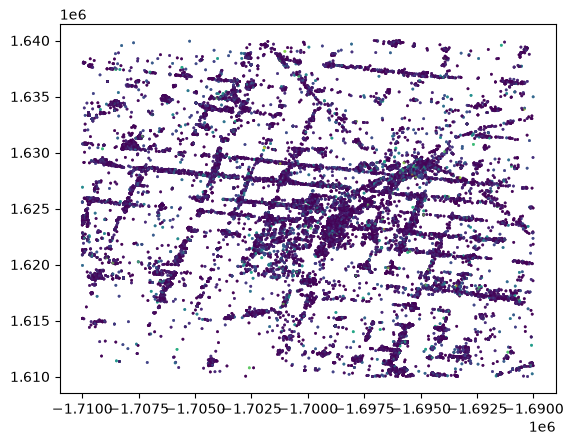

In [57]:
%matplotlib inline
plt.scatter(x, y, s=1, c=types,alpha=0.5)
plt.show()

In [63]:
print(type(g_enc_dec))

[m for m in dir(g_enc_dec) if not m.startswith("_")]

<class 'spacegraph_codebase.model.GlobalPositionEncoderDecoder'>


['T_destination',
 'activation',
 'add_module',
 'apply',
 'bfloat16',
 'buffers',
 'call_super_init',
 'children',
 'compile',
 'cpu',
 'cuda',
 'double',
 'dump_patches',
 'enc',
 'eval',
 'extra_repr',
 'float',
 'forward',
 'g_spa_dec',
 'g_spa_enc',
 'get_batch_scores',
 'get_buffer',
 'get_center_pt_embed',
 'get_center_pt_spa_coords',
 'get_extra_state',
 'get_neg_pt_embed',
 'get_parameter',
 'get_pred_embed_from_coords',
 'get_submodule',
 'half',
 'ipu',
 'load_state_dict',
 'modules',
 'mtia',
 'named_buffers',
 'named_children',
 'named_modules',
 'named_parameters',
 'num_neg_resample',
 'parameters',
 'pointset',
 'register_backward_hook',
 'register_buffer',
 'register_forward_hook',
 'register_forward_pre_hook',
 'register_full_backward_hook',
 'register_full_backward_pre_hook',
 'register_load_state_dict_post_hook',
 'register_load_state_dict_pre_hook',
 'register_module',
 'register_parameter',
 'register_state_dict_post_hook',
 'register_state_dict_pre_hook',
 'requi

In [65]:
import inspect

print(inspect.getsource(g_enc_dec.__class__.forward))

    def forward(self, ng_list, do_full_eval = True):
        '''
        Given a list of NeighborGraph(), 
            1. Compute the predicted center point feature embedding,
            2. Get the ground truth feature embedding for center points
            3. Get the N negative sampled center points feature embedding
        Args:
            do_full_eval: do we use the full negative samples to do evaluation
            ng_list: a list of NeighborGraph()
        Return:
            center_pred_embed: the predicted feature embedding for center points by using context points
                    shape (batch_size, embed_dim)
            center_embed: the ground truth feature embedding for center points
                    shape (batch_size, embed_dim)
            neg_embeds: the N negative sampled center points feature embedding
                    shape (batch_size, num_neg_sample, embed_dim)
        '''

        if do_full_eval == False:
            # random sample each context point

In [71]:
len(coords)

51

In [ ]:
with torch.no_grad():
    spa_embeds = g_enc_dec.g_spa_enc(coords)
    spa_embeds = spa_embeds.squeeze(1)

    pred_embeds = g_enc_dec.g_spa_dec(spa_embeds)

print(spa_embeds.shape)
print(pred_embeds.shape)

torch.Size([51, 44, 64])
torch.Size([51, 44, 64])


In [ ]:
feature_ids = [[i] for i in range(1191)]

with torch.no_grad():
    feature_embeds = g_enc_dec.enc.feature_embed_lookup(feature_ids)

feature_embeds = feature_embeds.squeeze(1)
print(feature_embeds.shape)

torch.Size([1191, 64])


In [83]:
with torch.no_grad():
    # [51, 44, 64] @ [64, 1191]
    scores = torch.matmul(pred_embeds, feature_embeds.T)

print(scores.shape)
pred_types = torch.argmax(scores, dim=-1)

print(pred_types.shape)
print(pred_types)

torch.Size([51, 44, 1191])
torch.Size([51, 44])
tensor([[ 843,  843, 1069,  ...,  428,  843,  843],
        [1069, 1069,  843,  ..., 1069, 1069, 1069],
        [1069, 1069, 1069,  ...,  428,  353, 1069],
        ...,
        [ 596, 1069, 1069,  ..., 1069,  531,  842],
        [ 654, 1069,  843,  ...,  843,  843,  843],
        [1069, 1069, 1069,  ...,  649,  843, 1069]])


In [84]:
from collections import Counter

counts = Counter(pred_types.flatten().tolist())

for type_id, count in counts.most_common():
    print(type_id, count)

1069 958
843 726
428 129
531 120
842 64
654 39
451 32
732 30
596 28
727 21
649 20
693 17
353 8
937 6
59 6
899 5
731 5
501 5
312 4
491 3
1102 3
983 3
1003 2
369 2
1033 2
855 1
345 1
919 1
129 1
464 1
691 1
